In [2]:
import numpy as np
import pandas as pd
import datetime as dt
import matplotlib.pyplot as plt



pd.set_option('display.max_columns', None)

In [3]:
colorlist = ["xkcd:magenta", "xkcd:blue green", "xkcd:grey", "xkcd:sky blue", "xkcd:light orange",
             "xkcd:grey blue", "xkcd:dark yellow", "xkcd:pale purple", "xkcd:coral",
             "xkcd:ocean blue", "xkcd:light olive", "xkcd:reddish brown", "xkcd:dark lavender", "xkcd:forrest green", 
             "xkcd:terracotta", "xkcd:light cyan", "xkcd:orchid", "xkcd:puke yellow", "xkcd:periwinkle blue"]

In [4]:
def rnf(filepath, dt_form): # function for reading and formatting dataframes from csv-like file
        
    # Read in file
    # Create column of datetime objects from the 'TIMESTAMP COLUMN'
    # Need to shift it 6 hours to put in local time (TIMESTAMP column is in UTC)
    if dt_form == 'EP':
        df = pd.read_csv(filepath, header = [1], skiprows= [2]) #read in file
        df['dt_ts'] = pd.to_datetime(df['date']+df['time'], format = '%Y-%m-%d%H:%M') - dt.timedelta(hours = 6)
    elif dt_form == 'DL':
        df = pd.read_csv(filepath) #read in file
        df['dt_ts'] = pd.to_datetime(df['TIMESTAMP'], format = '%Y-%m-%d %H:%M:%S') - dt.timedelta(hours = 6)
    
    r = pd.date_range(start=dt.datetime(2025, 6, 1), end=dt.datetime(2025, 9, 9), freq = '30min')
    df = df.set_index('dt_ts').reindex(r).rename_axis('dt_ts')

    df = df.map(lambda x: np.nan if x == -9999 else x) #convert -9999 to nan

    return(df)

In [5]:
base_dir1 = 'C:\\Users\\emily\\Documents\\Grad_School\\Research\\Agrivoltaics\\Data_processing\\EddyPro\\EP_Output\\'
# KSC = rnf(base_dir1 + 'KSC_summer\\eddypro_KSC_full_output_2025-07-31T173612_adv.csv', dt_form = 'EP')
# KSA = rnf(base_dir1 + 'KSA_summer\\eddypro_KSA_full_output_2025-07-31T194050_adv.csv', dt_form = 'EP')

KSC = rnf('C:\\Users\\emily\\Documents\\Grad_School\\Research\\Agrivoltaics\\Data_processing\\Datalogger_output_fluxes\\2025_controltow_flux.csv', dt_form = 'DL')
KSA = rnf('C:\\Users\\emily\\Documents\\Grad_School\\Research\\Agrivoltaics\\Data_processing\\Datalogger_output_fluxes\\2025_arraytow_flux.csv', dt_form = 'DL')

base_dir2 = 'C:\\Users\\emily\\Documents\\Grad_School\\Research\\Agrivoltaics\\Data_processing\\Datalogger_output_fluxes\\'
KSA_NR =rnf(base_dir2 + '2025_arraytow_netrad.csv', dt_form = 'DL')
KSC_NR =rnf(base_dir2 + '2025_controltow_netrad.csv', dt_form = 'DL')




In [8]:
var = 'w_rot'
KSA_day = KSA[var].where((KSA.index.hour>=9)&(KSA.index.hour<=19))
KSC_day = KSC[var].where((KSC.index.hour>=9)&(KSC.index.hour<=19))
diff = (KSA_day- KSC_day)
# plt.plot(KSA[var])
# plt.plot(KSC[var])
# plt.plot((KSA[var] - KSC[var]).groupby(KSA.index.date).mean())
# plt.plot((KSA[var]).groupby(KSA.index.date).mean())
plt.scatter(KSC['air_temperature'], diff)
plt.xticks(rotation = 45);
# plt.ylim(-40, 40)

KeyError: 'w_rot'

In [ ]:
KSA_day = KSA[var].groupby(([KSA.index.hour, KSA.index.minute])).mean()
KSC_day = KSC[var].groupby(([KSC.index.hour, KSC.index.minute])).mean()
plt.plot(hours, KSA_day, c = colorlist[5], label = 'KSA')
plt.plot(hours, KSC_day, c = colorlist[10], label = 'KSC')
# plt.plot(hours, KSA_day - KSC_day, c = colorlist[6], label = 'difference')
plt.xlabel('local time [hours]')
plt.ylabel('Mean vertical velocity [m/s]')
plt.legend()

NameError: name 'hours' is not defined

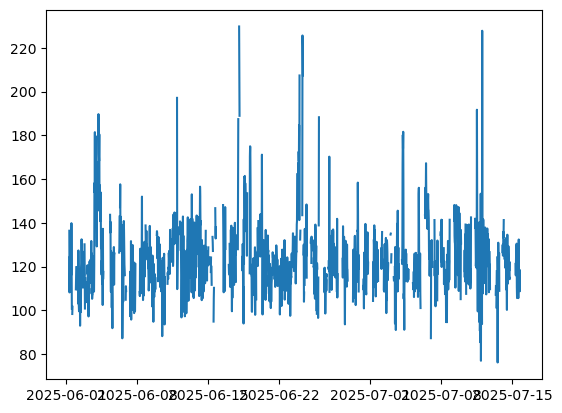

In [ ]:
plt.plot(KSA['x_70%'])

In [ ]:
KSA.columns[0:50]

Index(['filename', 'date', 'time', 'DOY', 'daytime', 'file_records',
       'used_records', 'Tau', 'qc_Tau', 'rand_err_Tau', 'H', 'qc_H',
       'rand_err_H', 'LE', 'qc_LE', 'rand_err_LE', 'co2_flux', 'qc_co2_flux',
       'rand_err_co2_flux', 'h2o_flux', 'qc_h2o_flux', 'rand_err_h2o_flux',
       'H_strg', 'LE_strg', 'co2_strg', 'h2o_strg', 'co2_v-adv', 'h2o_v-adv',
       'co2_molar_density', 'co2_mole_fraction', 'co2_mixing_ratio',
       'co2_time_lag', 'co2_def_timelag', 'h2o_molar_density',
       'h2o_mole_fraction', 'h2o_mixing_ratio', 'h2o_time_lag',
       'h2o_def_timelag', 'sonic_temperature', 'air_temperature',
       'air_pressure', 'air_density', 'air_heat_capacity', 'air_molar_volume',
       'ET', 'water_vapor_density', 'e', 'es', 'specific_humidity', 'RH'],
      dtype='object')

In [ ]:
a = pd.read_csv((base_dir + 'KSA_summer\\eddypro_KSC_full_output_2025-07-17T180432_adv.csv'), header = [1, 2])
a

,filename,date,time,DOY,daytime,file_records,used_records,Tau,qc_Tau,rand_err_Tau,H,qc_H,rand_err_H,LE,qc_LE,rand_err_LE,co2_flux,qc_co2_flux,rand_err_co2_flux,h2o_flux,qc_h2o_flux,rand_err_h2o_flux,H_strg,LE_strg,co2_strg,h2o_strg,co2_v-adv,h2o_v-adv,co2_molar_density,co2_mole_fraction,co2_mixing_ratio,co2_time_lag,co2_def_timelag,h2o_molar_density,h2o_mole_fraction,h2o_mixing_ratio,h2o_time_lag,h2o_def_timelag,sonic_temperature,air_temperature,air_pressure,air_density,air_heat_capacity,air_molar_volume,ET,water_vapor_density,e,es,specific_humidity,RH,VPD,Tdew,u_unrot,v_unrot,w_unrot,u_rot,v_rot,w_rot,wind_speed,max_wind_speed,wind_dir,yaw,pitch,roll,u*,TKE,L,(z-d)/L,bowen_ratio,T*,model,x_peak,x_offset,x_10%,x_30%,x_50%,x_70%,x_90%,un_Tau,Tau_scf,un_H,H_scf,un_LE,LE_scf,un_co2_flux,co2_scf,un_h2o_flux,h2o_scf,spikes_hf,amplitude_resolution_hf,drop_out_hf,absolute_limits_hf,skewness_kurtosis_hf,skewness_kurtosis_sf,discontinuities_hf,discontinuities_sf,timelag_hf,timelag_sf,attack_angle_hf,non_steady_wind_hf,u_spikes,v_spikes,w_spikes,ts_spikes,co2_spikes,h2o_spikes,u_var,v_var,w_var,ts_var,co2_var,h2o_var,w/ts_cov,w/co2_cov,w/h2o_cov,fast_t_mean
,Unnamed: 0_level_1,[yyyy-mm-dd],[HH:MM],[ddd.ddd],[1=daytime],[#],[#],[kg+1m-1s-2],[#],[kg+1m-1s-2],[W+1m-2],[#],[W+1m-2],[W+1m-2],[#],[W+1m-2],[µmol+1s-1m-2],[#],[µmol+1s-1m-2],[mmol+1s-1m-2],[#],[mmol+1s-1m-2],[W+1m-2],[W+1m-2],[µmol+1s-1m-2],[mmol+1s-1m-2],[µmol+1s-1m-2],[mmol+1s-1m-2],[mmol+1m-3],[µmol+1mol_a-1],[µmol+1mol_d-1],[s],[1=default],[mmol+1m-3],[mmol+1mol_a-1],[mmol+1mol_d-1],[s],[1=default],[K],[K],[Pa],[kg+1m-3],[J+1kg-1K-1],[m+3mol-1],[mm+1hour-1],[kg+1m-3],[Pa],[Pa],[kg+1kg-1],[%],[Pa],[K],[m+1s-1],[m+1s-1],[m+1s-1],[m+1s-1],[m+1s-1],[m+1s-1],[m+1s-1],[m+1s-1],[deg_from_north],[deg],[deg],[deg],[m+1s-1],[m+2s-2],[m],[#],[#],[K],[0=KJ/1=KM/2=HS],[m],[m],[m],[m],[m],[m],[m],[kg+1m-1s-2],[#],[W+1m-2],[#],[W+1m-2],[#],[µmol+1s-1m-2],[#],[mmol+1s-1m-2],[#],8u/v/w/ts/co2/h2o/ch4/none,8u/v/w/ts/co2/h2o/ch4/none,8u/v/w/ts/co2/h2o/ch4/none,8u/v/w/ts/co2/h2o/ch4/none,8u/v/w/ts/co2/h2o/ch4/none,8u/v/w/ts/co2/h2o/ch4/none,8u/v/w/ts/co2/h2o/ch4/none,8u/v/w/ts/co2/h2o/ch4/none,8co2/h2o/ch4/none,8co2/h2o/ch4/none,8aa,8U,[#],[#],[#],[#],[#],[#],[m+2s-2],[m+2s-2],[m+2s-2],[K+2],--,--,[m+1K+1s-1],--,--,--
0,agrivoltaics2_ts_data_2025_06_01_0000.dat,2025-06-01,00:30,152.0208,0,18000,18000,-0.032032,0,0.005701,4.13376,1,2.83176,17.459900,1,4.610170,-0.395059,0,0.345286,0.395341,1,0.104387,-9999.000000,-9999.000000,-9999.000000,-9999.000000,68.65130,0.966932,15.9237,396.813,399.044,0.0,0,224.281,5.58898,5.62040,0.0,0,294.473,293.952,98246.0,1.16193,1008.58,0.024920,0.025618,0.004042,548.268,2449.34,0.003478,22.3844,1901.07,271.668,-0.521946,-0.711545,-0.045496,0.883513,3.315830e-14,0.004311,0.883523,2.718820,127.324,233.8040,-9999,-9999,0.166036,0.198748,-95.317200,-0.073439,0.236758,-0.021245,0,-9999.0000,-9999.00000,-9999.0000,-9999.0000,-9999.0000,-9999.000,-9999.000,-0.031232,1.02560,5.10916,1.01867,16.861300,1.02267,-0.726306,1.02267,0.381788,1.02267,899999999,800000099,800000099,800000099,800001099,800011099,899999999,899999999,89999,89999,89,89,8,4,2,17,5,1,0.190696,0.159917,0.046882,0.044387,0.000919,74.0094,0.004360,-0.000726,0.381788,19.9478
1,agrivoltaics2_ts_data_2025_06_01_0030.dat,2025-06-01,01:00,152.0416,0,18000,18000,-0.007505,0,0.001556,-2.41035,1,2.91397,8.577180,1,2.764200,0.513056,0,0.431120,0.194062,1,0.062541,-4.691530,2.366650,0.430126,0.053546,-119.46900,-1.753380,16.0492,398.952,401.301,0.0,0,235.545,5.85519,5.88968,0.0,0,293.698,293.153,98229.9,1.16479,1008.70,0.024858,0.012575,0.004245,574.240,2331.51,0.003644,24.6295,1757.27,272.299,-0.708335,-0.308456,-0.036497,0.773444,1.742590e-15,-0.007444,0.773479,1.761310,154.907,203.6210,-9999,-9999,0.080272,0.079403,18.470700,0.378979,-0.281019,0.025557,0,-9999.0000,-9999.00000,-9999.0000,-9999.0000,-9999.0000,-9999.000,-9999.000,-0.007434,1.00964,-1.86554,1.01222,8.428050,1.02039,0.537124,1.02039,0.190688,1.02039,